In [1]:
import os
import time
import platform
from shutil import rmtree
from dotenv import load_dotenv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as image
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset, random_split

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':  # Mac OS
    plt.rc('font', family='AppleGothic')
else:  # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 오류 발생시
sklearn.set_config(display="text")

# Intel Image Classification 분류 데이터셋
- Intel Image Classification 데이터셋은 인텔(Intel)이 호스팅한 해커톤/컴퓨터 비전 경진대회용 데이터셋으로,  
  자연 풍경 및 도시 공간 이미지로 구성된 6개 클래스 분류 데이터셋입니다.

[Intel Image Classification 링크](https://www.kaggle.com/datasets/puneet6060/intel-image-classification)

### Intel Image Classification 클래스 정보 (6개)
| 클래스 번호 | 클래스명 (영문) | 설명 (한글) |
| :---: | :---: | :---: |
| 0 | buildings | 건물 |
| 1 | forest | 숲 |
| 2 | glacier | 빙하 |
| 3 | mountain | 산 |
| 4 | sea | 바다 |
| 5 | street | 거리 |


### 이미지 데이터 크기
- Intel Image Classification 데이터셋의 원본 이미지는 150 × 150 픽셀 크기로 구성되어 있습니다. 단일 이미지 한 장을 기준으로 볼 때 전체 픽셀 수는 총 22,500개에 해당합니다. 만약 이 데이터가 흑백(Grayscale) 이미지라면 단일 채널이므로 입력 필드의 값이 22,500개가 되지만, 해당 데이터셋은 RGB 컬러 이미지이므로 Red, Green, Blue에 해당하는 3개의 색상 레이어가 각각 존재하게 됩니다. 이에 따라 이미지 한 장당 실제 모델에 입력되는 값은 22,500에 3을 곱한 총 67,500개의 필드 데이터로 확장됩니다.

In [2]:
load_dotenv()

print(os.environ["KAGGLE_API_TOKEN"][:10])

KGAT_24595


In [3]:
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()

output_dir = r"C:\kdt_0900_hhj\ml\resource\dataset"
#없으면 생성
os.makedirs(output_dir, exist_ok=True)

api.dataset_download_files(r"puneet6060/intel-image-classification", path=output_dir, unzip=True)

print("Inter Image 다운로드 완료")

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
Inter Image 다운로드 완료


In [4]:
categories = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

class_names = dict(enumerate(categories))
class_names

{0: 'buildings',
 1: 'forest',
 2: 'glacier',
 3: 'mountain',
 4: 'sea',
 5: 'street'}

In [5]:
base_path = output_dir
train_path = os.path.join(base_path, "seg_train", "seg_train")
test_path = os.path.join(base_path, "seg_test", "seg_test")

## ※ transforms.Normalize(mean, std)
- 텐서로 변환된 이미지의 픽셀 값을 정규화(normalization)합니다.
- mean: 각 채널(R, G, B)의 평균값. std: 각 채널의 표준편차.
- mean=[0.5, 0.5, 0.5]: R, G, B 채널 각각의 평균을 0.5로 설정.
- std=[0.5, 0.5, 0.5]: R, G, B 채널 각각의 표준편차를 0.5로 설정.
- 이 정규화는 일반적으로 픽셀 값의 범위를 [-1,1] [-1, 1][-1,1]로 조정하기 위해 사용됩니다.
- (픽셀 값이 [O,1][O,1][0,1]로 변환된 상태에서 == toTensor를 한 상태에서)
    - 예) x = [0.2, 0.4, 0.7, 0.9] 경우 모두 양수이므로 그대로 통과
    - 예) x = [-0.8,-0.2, 0.3, 0.91] 경우 ReLU를 통과하면 [0.0, 0.0, 0.3, 0.9]
      - 0.0으로 죽는 값이 생기지만 그런 값들을 살짝의 음수로 바꾸어 살리기 위한 목적으로 사용한다.
     
## ※ datasets.ImageFolder()
- 이미지 데이터를 특정 디렉터리 구조에서 로드하는 클래스입니다.  
디렉터리 이름을 레이블(class label)로 간주하며, 각 디렉터리 내의 이미지 파일들을 해당 레이블에 할당합니다.  
이 클래스는 이미지 데이터를 PyTorch 데이터셋(Dataset) 형식으로 변환하므로, DataLoader와 함께 사용하여  
배치 처리 및 데이터 증강 (data augmentation)을 쉽게 적용할 수 있습니다.

In [6]:
train_transform = transforms.Compose([
    # transforms.Resize() : 보통 리사이즈가 필요함. 이유: 이미지마다 크기가 다를 수있기때문 but! 지금 우리의 데이터는 다 같아서 필요x
    transforms.Resize((150, 150)), #그냥 했슨
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5],
    )
])

test_transform = transforms.Compose([ #Compose → 여러 변환(transform)을 순서대로 묶어주는 것
    transforms.Resize((150, 150)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5],
    )
])

In [7]:
full_train_dataset = ImageFolder(train_path, transform=train_transform)
full_train_dataset

total_size = len(full_train_dataset)
val_size = int(total_size * 0.2)
train_size = total_size - val_size
print(total_size, train_size, val_size)

train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(2026))
test_dataset = ImageFolder(test_path, transform=test_transform)


print(len(train_dataset), len(val_dataset))
print(len(test_dataset))
#나누고 스플릿하고 텐서로만들고 정규화하고 이런거 한번에 한거임

14034 11228 2806
11228 2806
3000


In [8]:
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [9]:
imgs, labels = next(iter(train_dataloader))

In [10]:
print(imgs.shape)
print(labels.shape)

torch.Size([64, 3, 150, 150])
torch.Size([64])


In [11]:
def imshow(img):
    img = img.numpy().transpose((1, 2, 0)) #차원 바꾸기 150 x150 x3와같이 이미지크기x컬러 이케 되는건데 3을 ㅇ앞으로 보낸거임
    mean = np.array([0.5, 0.5, 0.5])
    std = np.array([0.5, 0.5, 0.5])

    # 정규화를 원래대로 되돌림
    img = img * std + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.show()

['buildings', 'sea', 'street', 'glacier']


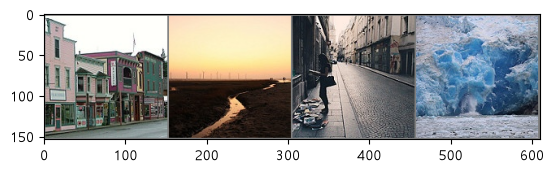

In [12]:
print([class_names[labels[i].item()] for i in range(4)])
out = make_grid(imgs[:4])
imshow(out)

In [13]:
class Model1(nn.Module):
    def __init__(self):
        super(Model1, self).__init__() #상속?
        self.linear = nn.Linear(150*150*3, 6) #펼친 개수만큼 특성이 들어오고 분류개수만큼 내보내기
        self.flatten = nn.Flatten()

    # Module의 상속받은 메서드
    def forward(self,x):
        x = self.flatten(x)
        x = self.linear(x)
        return x

In [14]:
class Model2(nn.Module):
    def __init__(self):
        super(Model1, self).__init__()
        self.linear1 = nn.Linear(150*150*3, 6)
        self.linear2 = nn.Linear(64, 6)
        self.flatten = nn.Flatten()

    def forward(self,x):
        x = self.flatten(x)
        x = self.linear1(x)
        x = self.linear2(x)
        return x

In [15]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.mps.is_available():
    device = torch.device("mps")
elif torch.xpu.is_available():
    device = torch.device("xpu")
else:
    device = torch.device("cpu")

print(f"현재 선택된 장치: {device}")

현재 선택된 장치: cuda


In [16]:
model1 = Model1().to(device)

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model1.parameters(), lr=0.001)

In [18]:
log_step = 10 #10번마다
epochs = 15

# 가장 좋았던 지점을 저장하기 위해 변수
best_val_acc = 0
best_apoch = 0

# epoch 마다 history
history = []
accuracy = []

In [19]:
#가중치패스만들기
model1_path = os.path.join(base_path, r"weights/Model1")
model2_path = os.path.join(base_path, r"weights/Model2")
model3_path = os.path.join(base_path, r"weights/Model3")

In [20]:
os.makedirs(model1_path, exist_ok=True)
os.makedirs(model2_path, exist_ok=True)
os.makedirs(model3_path, exist_ok=True)

In [21]:
def train_one_epoch(model, dataloader, criterion, optimizer, device="cpu"):
    model.train()

    sum_losses = 0.0
    sum_accs = 0.0

    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # 학습
        optimizer.zero_grad()
        y_pred = model(X_batch) # 순전파
        loss = criterion(y_pred, y_batch)
        loss.backward() # 역전파
        optimizer.step() # 기울기 업데이트

        sum_losses += loss
        y_pred_index = y_pred.argmax(dim=1)
        acc = (y_batch == y_pred_index).float().mean().item() * 100
        sum_accs += acc

    avg_loss = sum_losses / len(dataloader)
    avg_acc = sum_accs / len(dataloader)
    return avg_loss, avg_acc

In [22]:
@torch.no_grad()
def evaluate(model, dataloader, criterion, device="cpu"):
    model.eval()
    sum_losses = 0.0
    sum_accs = 0.0

    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # 평가
        y_pred = model(X_batch) # 순전파
        loss = criterion(y_pred, y_batch)

        sum_losses += loss
        y_pred_index = y_pred.argmax(dim=1)
        acc = (y_batch == y_pred_index).float().mean().item() * 100
        sum_accs += acc

    avg_loss = sum_losses / len(dataloader)
    avg_acc = sum_accs / len(dataloader)
    return avg_loss, avg_acc

In [23]:
def train_model(model, model_name, train_loader, val_loader, criterion, optimizer, epochs, device, save_base_dir):
    save_dir = os.path.join(save_base_dir, model_name)
    os.makedirs(save_dir, exist_ok=True)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0.0

    # 학습 시작
    print(f"------------{model_name} 학습 시작 --------------")
    for epoch in range(epochs):
        lr = optimizer.param_groups[0]["lr"]

        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        print(f"Epoch: {epoch + 1} | Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.2f}%")
        print(f"Epoch: {epoch + 1} | Validation Loss: {val_loss:.4f} | Validation Accuracy: {val_acc:.2f}%")

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), os.path.join(save_dir, "best_model.pth"))

    torch.save(model.state_dict(), os.path.join(save_dir, f"last_model_{epochs}.pth"))
    print(f"------------{model_name} 학습 완료 --------------")

    return history

In [36]:
model1 = Model1().to(device)
optimizer1 = optim.Adam(model1.parameters(), lr=0.001)

history1 = train_model(
    model=model1, 
    model_name="Model1", 
    train_loader=train_dataloader, 
    val_loader=val_dataloader,
    criterion=criterion, 
    optimizer=optimizer1, 
    epochs=10, 
    device=device, 
    save_base_dir=os.path.join(base_path, "weights")
)

------------Model1 학습 시작 --------------
Epoch: 1 | Train Loss: 4.1203 | Train Accuracy: 41.30%
Epoch: 1 | Validation Loss: 2.8944 | Validation Accuracy: 44.49%
Epoch: 2 | Train Loss: 3.2471 | Train Accuracy: 46.63%
Epoch: 2 | Validation Loss: 4.7642 | Validation Accuracy: 38.61%
Epoch: 3 | Train Loss: 3.0977 | Train Accuracy: 50.07%
Epoch: 3 | Validation Loss: 3.6667 | Validation Accuracy: 45.82%
Epoch: 4 | Train Loss: 3.0868 | Train Accuracy: 52.08%
Epoch: 4 | Validation Loss: 3.4948 | Validation Accuracy: 40.96%
Epoch: 5 | Train Loss: 2.9245 | Train Accuracy: 54.40%
Epoch: 5 | Validation Loss: 3.5533 | Validation Accuracy: 44.55%
Epoch: 6 | Train Loss: 2.8419 | Train Accuracy: 55.89%
Epoch: 6 | Validation Loss: 4.2383 | Validation Accuracy: 41.81%
Epoch: 7 | Train Loss: 2.3512 | Train Accuracy: 59.24%
Epoch: 7 | Validation Loss: 5.3202 | Validation Accuracy: 41.78%
Epoch: 8 | Train Loss: 2.1666 | Train Accuracy: 61.11%
Epoch: 8 | Validation Loss: 4.6528 | Validation Accuracy: 42.30%


## 모델평가

In [27]:
base_model_path = os.path.join(base_path, "weights", "Model1", "best_model.pth")
base_model_path # 가장 잘 만든 모델로 들고와서 평가

model1.load_state_dict(torch.load(base_model_path, weights_only=False))

<All keys matched successfully>

In [29]:
test_loss, test_acc = evaluate(model1, test_dataloader, criterion, device)

In [30]:
print(f"최종 Test Model1 | Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f}%")

최종 Test Model1 | Test Loss: 3.5695 | Test Accuracy: 43.45%


결론: 음

### 모델 2 로 다시 보기 

In [31]:
class Model2(nn.Module):
    def __init__(self):
        super(Model2, self).__init__()
        self.linear1 = nn.Linear(150*150*3, 64)
        self.linear2 = nn.Linear(64, 6)
        self.flatten = nn.Flatten()
        
    # Module의 상속받은 메서드
    def forward(self, x):
        x = self.flatten(x)
        x = self.linear1(x)
        x = self.linear2(x)
        return x

In [37]:
model2 = Model2().to(device)
optimizer2 = optim.Adam(model2.parameters(), lr=0.001)

history2 = train_model(
    model=model2, 
    model_name="Model2", 
    train_loader=train_dataloader, 
    val_loader=val_dataloader,
    criterion=criterion, 
    optimizer=optimizer2, 
    epochs=10, 
    device=device, 
    save_base_dir=os.path.join(base_path, "weights")
)

------------Model2 학습 시작 --------------
Epoch: 1 | Train Loss: 4.2007 | Train Accuracy: 41.33%
Epoch: 1 | Validation Loss: 1.7421 | Validation Accuracy: 46.92%
Epoch: 2 | Train Loss: 1.2702 | Train Accuracy: 54.10%
Epoch: 2 | Validation Loss: 1.3058 | Validation Accuracy: 51.31%
Epoch: 3 | Train Loss: 1.1536 | Train Accuracy: 57.76%
Epoch: 3 | Validation Loss: 1.3815 | Validation Accuracy: 50.24%
Epoch: 4 | Train Loss: 1.1317 | Train Accuracy: 58.69%
Epoch: 4 | Validation Loss: 1.2925 | Validation Accuracy: 53.57%
Epoch: 5 | Train Loss: 1.1039 | Train Accuracy: 59.90%
Epoch: 5 | Validation Loss: 1.3386 | Validation Accuracy: 51.17%
Epoch: 6 | Train Loss: 1.0901 | Train Accuracy: 60.23%
Epoch: 6 | Validation Loss: 1.3705 | Validation Accuracy: 48.20%
Epoch: 7 | Train Loss: 1.0642 | Train Accuracy: 61.45%
Epoch: 7 | Validation Loss: 1.4095 | Validation Accuracy: 49.69%
Epoch: 8 | Train Loss: 1.0581 | Train Accuracy: 61.30%
Epoch: 8 | Validation Loss: 1.3857 | Validation Accuracy: 50.27%


In [33]:
base_model_path = os.path.join(base_path, "weights", "Model2", "best_model.pth")
base_model_path # 가장 잘 만든 모델로 들고와서 평가

model2.load_state_dict(torch.load(base_model_path, weights_only=False))

<All keys matched successfully>

In [34]:
test_loss, test_acc = evaluate(model2, test_dataloader, criterion, device)

In [35]:
print(f"최종 Test Model2 | Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f}%")

최종 Test Model2 | Test Loss: 1.4007 | Test Accuracy: 50.21%


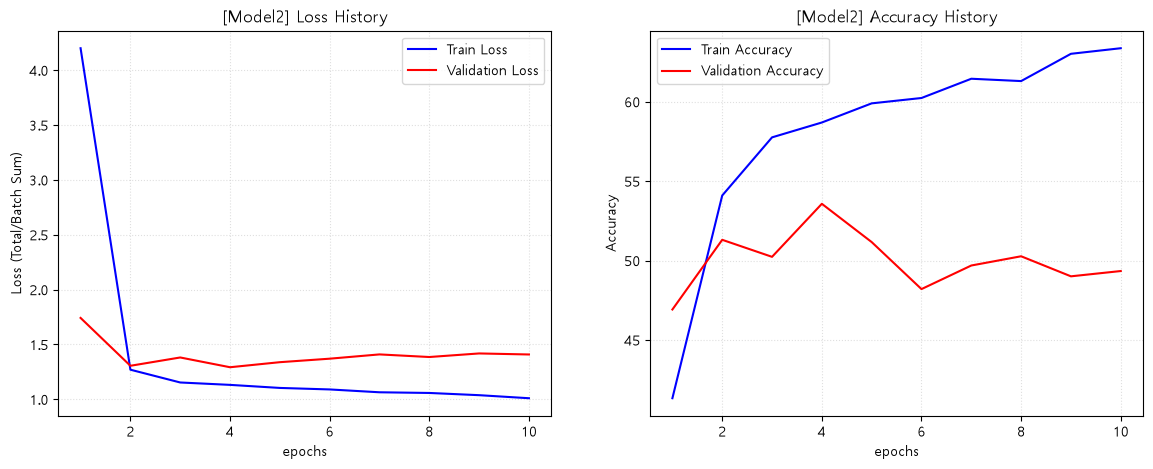

In [39]:
def plot_history(history, model_name):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    extract_vals = lambda lst: [x.detach().cpu().item() if isinstance(x, torch.Tensor) else float(x) for x in lst]
    
    axes[0].plot(epochs, extract_vals(history["train_loss"]), "blue", label="Train Loss")
    axes[0].plot(epochs, extract_vals(history["val_loss"]), "red", label="Validation Loss")
    axes[0].set_title(f"[{model_name}] Loss History")
    axes[0].set_xlabel("epochs")
    axes[0].set_ylabel("Loss (Total/Batch Sum)")
    axes[0].grid(True, linestyle=":", alpha=0.4)
    axes[0].legend()
    
    axes[1].plot(epochs, extract_vals(history["train_acc"]), "blue", label="Train Accuracy")
    axes[1].plot(epochs, extract_vals(history["val_acc"]), "red", label="Validation Accuracy")
    axes[1].set_title(f"[{model_name}] Accuracy History")
    axes[1].set_xlabel("epochs")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid(True, linestyle=":", alpha=0.4)
    axes[1].legend()

    plt.show()


plot_history(history2, "Model2")

In [40]:
class Model3(nn.Module):
    def __init__(self):
        super(Model3, self).__init__()
        # self.linear1 = nn.Linear(150*150*3, 128)
        # self.linear2 = nn.Linear(128, 64)
        # self.linear3 = nn.Linear(64, 32)
        # self.linear4 = nn.Linear(32, 6)

        # self.dropout1 = nn.Dropout(0.5)
        # self.dropout2 = nn.Dropout(0.5)
        # self.dropout3 = nn.Dropout(0.5)
        
        # self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(150*150*3, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(32, 6),
        )
        
    # Module의 상속받은 메서드
    def forward(self,x):
        return x


    # def forward(self, x):
    #     x = self.flatten(x)
        
    #     x = self.linear1(x)
    #     x = self.dropout1(x)
    #     x = self.linear2(x)
    #     x = self.dropout2(x)
    #     x = self.linear3(x)
    #     x = self.dropout3(x)
    #     x = self.linear4(x)

In [41]:
class Model3(nn.Module):
    def __init__(self):
        super(Model3, self).__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(150 * 150 * 3, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(32, 6)
        )
        
    # Module의 상속받은 메서드
    def forward(self, x):
        return self.net(x)

In [42]:
model3 = Model3().to(device)
optimizer2 = optim.Adam(model3.parameters(), lr=0.001)

history2 = train_model(
    model=model3, 
    model_name="Model3", 
    train_loader=train_dataloader, 
    val_loader=val_dataloader,
    criterion=criterion, 
    optimizer=optimizer2, 
    epochs=10, 
    device=device, 
    save_base_dir=os.path.join(base_path, "weights")
)

------------Model3 학습 시작 --------------
Epoch: 1 | Train Loss: 1.9263 | Train Accuracy: 26.93%
Epoch: 1 | Validation Loss: 1.5673 | Validation Accuracy: 42.33%
Epoch: 2 | Train Loss: 1.6143 | Train Accuracy: 34.87%
Epoch: 2 | Validation Loss: 1.4330 | Validation Accuracy: 44.75%
Epoch: 3 | Train Loss: 1.5290 | Train Accuracy: 37.69%
Epoch: 3 | Validation Loss: 1.3924 | Validation Accuracy: 46.51%
Epoch: 4 | Train Loss: 1.4888 | Train Accuracy: 39.43%
Epoch: 4 | Validation Loss: 1.3598 | Validation Accuracy: 47.10%
Epoch: 5 | Train Loss: 1.4492 | Train Accuracy: 41.90%
Epoch: 5 | Validation Loss: 1.3377 | Validation Accuracy: 48.21%
Epoch: 6 | Train Loss: 1.4201 | Train Accuracy: 43.57%
Epoch: 6 | Validation Loss: 1.2911 | Validation Accuracy: 49.94%
Epoch: 7 | Train Loss: 1.3970 | Train Accuracy: 44.94%
Epoch: 7 | Validation Loss: 1.3003 | Validation Accuracy: 46.47%
Epoch: 8 | Train Loss: 1.3580 | Train Accuracy: 46.00%
Epoch: 8 | Validation Loss: 1.2694 | Validation Accuracy: 52.05%


In [43]:
base_model_path = os.path.join(base_path, "weights", "Model3", "best_model.pth")
base_model_path # 가장 잘 만든 모델로 들고와서 평가

model3.load_state_dict(torch.load(base_model_path, weights_only=False))

<All keys matched successfully>

In [44]:
test_loss, test_acc = evaluate(model3, test_dataloader, criterion, device)

In [45]:
print(f"최종 Test Model3 | Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f}%")

최종 Test Model3 | Test Loss: 1.2555 | Test Accuracy: 51.78%
